# 14. Change detection

`sylva.change` compares two epochs of one plot: which trees died, which were
recruited, how much the survivors grew, and where the points, surfaces, voxels
and cylinder models differ. Every change is reported with an uncertainty or a
level of detection, and what the data cannot support is labelled rather than
reported as change. The [guide](../guide/change.md) has the details.

This notebook runs on `synthetic.forest_epochs`, a 30 m plot scanned twice
from five positions with known changes between the scans, so every result can
be checked against the truth.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

tmp = Path(tempfile.mkdtemp())      # files written here are temporary
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set
from sylva import change, filters, ground, qsm, trees, voxels

## Two epochs with known changes

Between the epochs the survivors grow by a known DBH and height increment,
two trees die, two are recruited (one of them 0.37 m from the stump of a dead
tree, as after felling), one tree loses a limb and part of one crown is
thinned. Epoch 2 is scanned with its own range noise (5 mm against 3 mm), from
scanners displaced by about 0.5 m, and is delivered in a frame rotated by
1.5 degrees and shifted by almost a metre, as an independently registered
revisit would be.

In [2]:
ep = synthetic.forest_epochs(seed=1)
cloud_1, cloud_2 = ep.clouds
print(f"epoch 1: {len(cloud_1):,} echoes, epoch 2: {len(cloud_2):,} echoes")
from collections import Counter
print("known changes:", dict(Counter(c["kind"] for c in ep.changes)))
truth_1 = ep.trees[0]                      # the trees of epoch 1, in the frame of epoch 1
print("trees in epoch 1:", len(truth_1["tree_id"]), " range noise (m):", ep.range_noise)

epoch 1: 652,715 echoes, epoch 2: 605,454 echoes
known changes: {'growth': 14, 'death': 2, 'branch_removed': 1, 'recruit': 2, 'foliage_thinned': 4}
trees in epoch 1: 16  range noise (m): (0.003, 0.005)


## Inventory, alignment and tree matching

Each epoch goes through the operational sequence of the trees guide: DTM,
stems, segmentation and heights. `align_epochs` then registers epoch 2 onto
epoch 1 on the stable features only (the stem axes and the terrain), since a
registration on all points would be pulled by the very change it should
reveal. Its uncertainty is part of the result.

In [3]:
def inventory(cloud):
    cloud = ground.normalize_height(cloud, ground.make_dtm(cloud))
    stems = trees.detect_stems(cloud)
    stems, _ = trees.merge_branches(cloud, stems)
    labels = trees.segment_trees(cloud, stems)
    trees.tree_heights(cloud, labels, stems)
    return trees.prune_trees(stems, labels) + (cloud,)


stems_1, labels_1, norm_1 = inventory(cloud_1)
stems_2, labels_2, norm_2 = inventory(cloud_2)
al = change.align_epochs(cloud_1, cloud_2)
print(al.report())

centre = np.array([15.0, 15.0, truth_1["z0"].mean(), 1.0])
error = (al.transform @ centre - ep.transform @ centre)[:3]
print("error at the plot centre (mm):", np.round(1000 * error, 2),
      " one sigma (mm):", np.round(1000 * al.sigma_xyz, 2))

Epoch alignment on stems+ground
  stems matched     14  (residual sigma 2.0 mm per axis)
  terrain samples   1448  (residual sigma 5.0 mm)
  registration sigma 1.3 mm (horizontal 0.9, vertical 0.9)
  coarse: [ok  ] new -> reference: stems=14 amb=0.21 fitness=0.666 above=0.749 dz=+0.1cm rmse=  44.4 mm stem=0.1cm (shift from coarse 5.0 cm)
error at the plot centre (mm): [ 0.01  0.01 -0.82]  one sigma (mm): [0.54 0.53 0.63]


`match_trees` moves the stems of epoch 2 into the frame of epoch 1 and
pairs them by an optimal assignment. Stems do not shrink, so the felled tree
and the recruit beside its stump are a death and a recruit, not one tree that
lost two thirds of its diameter.

In [4]:
m = change.match_trees(stems_1, stems_2, transform=al)
print(m.counts())
for kind, found in (("death", m.deaths), ("recruit", m.recruits)):
    true = ep.of_kind(kind)
    for t in found:
        xy = np.array([t.x, t.y]) if kind == "death" else al.transform[:2, :2] @ [t.x, t.y] + al.transform[:2, 3]
        d = min(np.hypot(c["x"] - xy[0], c["y"] - xy[1]) for c in true)
        print(f"{kind:8s} at ({xy[0]:5.2f}, {xy[1]:5.2f}), DBH {100 * t.dbh:4.1f} cm: "
              f"{100 * d:.1f} cm from a true {kind}")

{'survivors': 14, 'deaths': 2, 'recruits': 2, 'merged': 0, 'split': 0}
death    at (16.22, 21.06), DBH 36.1 cm: 0.0 cm from a true death
death    at ( 9.81, 16.74), DBH 32.0 cm: 0.0 cm from a true death
recruit  at (16.19, 21.42), DBH 11.3 cm: 0.8 cm from a true recruit
recruit  at (26.05,  2.62), DBH  8.7 cm: 0.9 cm from a true recruit


## Increments and their detection limits

`tree_increments` measures each survivor's DBH increment on its stem profile
(paired circle fits at the same heights in both epochs, which cancels the
stem's own shape) and gives it a minimum detectable increment (MDI) at 95 %
confidence. The true increments are joined by position.

In [5]:
inc = change.tree_increments(m, norm_1, norm_2, labels_1, labels_2, noise_a=0.003, noise_b=0.005)
growth = {c["tree_id"]: c for c in ep.of_kind("growth")}
nearest = [int(truth_1["tree_id"][np.argmin(np.hypot(truth_1["x"] - x, truth_1["y"] - y))])
           for x, y in zip(inc["x"], inc["y"])]
table = inc.to_pandas()[["x", "y", "d_dbh", "d_dbh_mdi", "dbh_change", "d_height", "d_height_mdi", "height_change"]]
table.insert(0, "true_tree", nearest)
table.insert(4, "true_d_dbh", [growth[t]["d_dbh"] for t in nearest])
table.insert(8, "true_d_height", [growth[t]["d_height"] for t in nearest])
within = np.abs(table["d_dbh"] - table["true_d_dbh"]) <= table["d_dbh_mdi"]
print(f"DBH increment within its MDI of the truth: {within.sum()} of {len(table)}")
cols = [c for c in table.columns if c.startswith(("d_", "true_d")) or c.endswith("mdi")]
(table.assign(**{c: 1000 * table[c] for c in cols if "dbh" in c})
      .round({c: 1 for c in cols} | {"x": 1, "y": 1}).rename(columns={c: c + (" (mm)" if "dbh" in c else " (m)") for c in cols}))

DBH increment within its MDI of the truth: 14 of 14


,true_tree,x,y,d_dbh (mm),true_d_dbh (mm),d_dbh_mdi (mm),dbh_change,d_height (m),true_d_height (m),d_height_mdi (m),height_change
0,12,6.6,12.8,6.6,6.2,1.3,growth,0.9,0.9,1.1,below_detection
1,13,10.4,2.9,11.8,11.6,1.6,growth,0.6,0.6,1.2,below_detection
2,15,11.0,19.8,14.5,14.8,1.3,growth,0.8,0.8,1.1,below_detection
3,11,26.7,5.5,5.6,5.8,1.1,growth,0.1,0.5,1.4,below_detection
4,6,27.2,21.6,15.9,16.0,1.3,growth,0.3,0.3,1.0,below_detection
5,9,23.3,8.8,13.0,13.3,1.1,growth,0.6,0.7,1.3,below_detection
6,4,25.0,23.1,15.1,14.9,1.0,growth,0.3,0.3,1.1,below_detection
7,5,4.3,24.5,15.4,15.5,1.0,growth,0.7,0.7,1.2,below_detection
8,3,9.1,6.4,16.5,16.2,1.3,growth,0.5,0.5,1.0,below_detection
9,16,27.8,16.4,18.4,18.0,2.3,growth,0.6,0.6,0.9,below_detection


Two survivors grew by only 0.5 mm, less than a scan can resolve, and are
reported as `below_detection` rather than as growth. Every height increment
is below its detection level of about a metre: a tree top that no pulse hit
leaves no trace, so a height difference of a few decimetres between two scans
is not evidence of growth, even where it happens to be right.

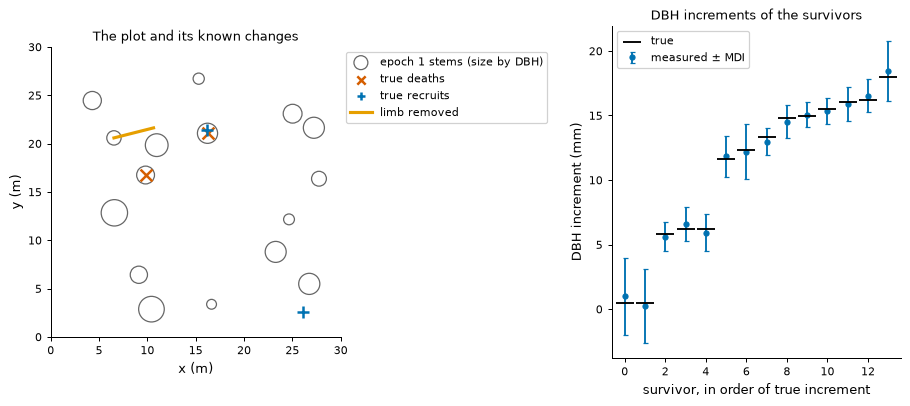

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.4))
ax[0].scatter(truth_1["x"], truth_1["y"], s=2000 * truth_1["dbh"] ** 2, facecolors="none", edgecolors="0.4",
              label="epoch 1 stems (size by DBH)")
for kind, marker, colour in (("death", "x", "C3"), ("recruit", "+", "C0")):
    pts = np.array([[c["x"], c["y"]] for c in ep.of_kind(kind)])
    ax[0].scatter(*pts.T, marker=marker, s=90, c=colour, linewidths=2, label=f"true {kind}s")
removed = ep.of_kind("branch_removed")[0]
ax[0].plot([removed["base_x"], removed["tip_x"]], [removed["base_y"], removed["tip_y"]], "C1", lw=2.5, label="limb removed")
ax[0].set(xlim=(0, 30), ylim=(0, 30), aspect="equal", xlabel="x (m)", ylabel="y (m)", title="The plot and its known changes")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), markerscale=0.7)
order = np.argsort(table["true_d_dbh"].to_numpy())
t = table.iloc[order]
ax[1].errorbar(np.arange(len(t)), 1000 * t["d_dbh"], yerr=1000 * t["d_dbh_mdi"], fmt="o", ms=4, c="C0",
               label="measured ± MDI")
ax[1].scatter(np.arange(len(t)), 1000 * t["true_d_dbh"], marker="_", s=200, c="k", label="true", zorder=3)
ax[1].set(xlabel="survivor, in order of true increment", ylabel="DBH increment (mm)", title="DBH increments of the survivors")
ax[1].legend(loc="upper left");

## The plot summary

`plot_summary` gives growth, mortality and recruitment per hectare and year,
with 95 % intervals from Monte Carlo draws of every tree's measurement errors.
The intervals cover measurement and registration only; a plot is still one
sample of its stand. The true basal-area figures come from the known trees.

In [7]:
summary = change.plot_summary(inc, area=30 * 30, years=5)
print(summary.report())

ha_yr = 30 * 30 / 1e4 * 5
ba = lambda d: np.pi / 4 * d ** 2
d1 = dict(zip(truth_1["tree_id"], truth_1["dbh"]))
true_growth = sum(ba(d1[t] + g["d_dbh"]) - ba(d1[t]) for t, g in growth.items()) / ha_yr
true_mortality = sum(ba(c["dbh"]) for c in ep.of_kind("death")) / ha_yr
for name, true in (("basal_area_growth", true_growth), ("basal_area_mortality", true_mortality)):
    e = summary[name]
    print(f"{name:21s} {e.estimate:.3f} [{e.low:.3f}, {e.high:.3f}] m²/ha/yr, true {true:.3f}")

quantity                     estimate              95 % interval  unit
n_survivors                        14                   [14, 14]  trees
n_deaths                            2                     [2, 2]  trees
n_recruits                          2                     [2, 2]  trees
n_ambiguous                         0                     [0, 0]  trees
mortality_rate               0.026353       [0.026353, 0.026353]  1/yr
recruitment_rate             0.026353       [0.026353, 0.026353]  1/yr
dbh_increment               0.0021738      [0.0020815, 0.002266]  m/yr
basal_area_growth               0.184         [0.17722, 0.19061]  m²/ha/yr
basal_area_mortality          0.40547         [0.39898, 0.41223]  m²/ha/yr
basal_area_recruitment       0.034936       [0.032595, 0.037374]  m²/ha/yr
basal_area_net               -0.18653       [-0.19589, -0.17695]  m²/ha/yr
volume_growth                  2.4517           [1.9331, 2.9668]  m³/ha/yr
volume_mortality               3.4554           [3.34

## Change in the points

`distances(a, b, "c2c")` gives, for each point of `b`, the distance to the
nearest point of `a`. Taken from the second epoch to the first
(`distances(epoch_2, epoch_1)`), it marks the points of epoch 1 that have no
counterpart in epoch 2: the dead trees, the removed limb and the thinned
foliage. It is unsigned and biased upwards by point spacing and noise, so it
serves as a first look rather than as a test.

In [8]:
cloud_2a = al.apply(cloud_2)                           # epoch 2 in the frame of epoch 1
gone = change.distances(cloud_2a, cloud_1, "c2c")      # for each point of epoch 1
print(gone, "| median", f"{100 * np.median(gone.distance):.1f} cm")
far = gone.distance > 0.3
print(f"{far.mean():.1%} of the epoch 1 points are more than 30 cm from any point of epoch 2")

PointDistances(c2c, n=652,715) | median 6.7 cm
10.1% of the epoch 1 points are more than 30 cm from any point of epoch 2


M3C2 (Lague et al. 2013) measures a signed distance along a normal with a
95 % level of detection. On a stem, radial normals make the distance the
radius increment. Here the core points are the epoch 1 stem points of one
survivor between 1 and 3 m, thinned to 5 cm; the registration uncertainty of
the alignment enters the level of detection.

In [9]:
tree = 3
k = list(truth_1["tree_id"]).index(tree)
cx, cy, z0 = truth_1["x"][k], truth_1["y"][k], truth_1["z0"][k]


def stem_band(c):
    r, h = np.hypot(c.x - cx, c.y - cy), c.z - z0
    return c[(r < 0.5) & (h > 1) & (h < 3) & (c.attrs["classification"] == 5)]


band_1, band_2 = stem_band(cloud_1), stem_band(cloud_2a)
core = filters.voxel_downsample(band_1, 0.05)
normals = np.column_stack([core.x - cx, core.y - cy, np.zeros(len(core))])
normals /= np.linalg.norm(normals, axis=1)[:, None]
m3 = change.distances(band_1, band_2, "m3c2", core, normals=normals, normal_scale=0.1,
                      projection_scale=0.15, max_depth=0.05, registration_sigma=al.registration_sigma)
print(m3)
print(f"median distance {1000 * np.nanmedian(m3.distance):.1f} mm, median LoD95 {1000 * np.nanmedian(m3.lod):.1f} mm, "
      f"{m3.significant.mean():.0%} significant; true radius increment {500 * growth[tree]['d_dbh']:.1f} mm")

PointDistances(m3c2, n=804, significant=735)
median distance 8.3 mm, median LoD95 5.7 mm, 91% significant; true radius increment 8.1 mm


A difference of rasters (`dod`) compares two surfaces on one lattice. With
canopy height models the dead trees show as large, coherent losses. The level
of detection is a fixed 1 m here, since scans from below do not see the upper
surface of a crown the same way twice; isolated cells still change by metres
where one epoch saw through a gap in the crowns and the other did not, which
is why a CHM difference from terrestrial scans needs a look at its spatial
pattern, not only at its significant cells.

significant over 159 of 930 m²: 303 m³ gained, 732 m³ lost


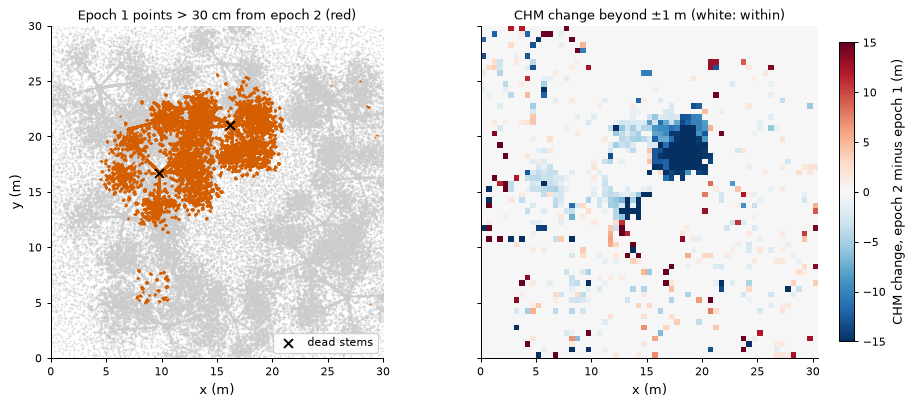

In [10]:
bounds = (0, 0, 30, 30)


def chm(cloud):
    cloud = ground.normalize_height(cloud, ground.make_dtm(cloud, 0.5, bounds=bounds))
    return ground.make_chm(cloud, 0.5, bounds=bounds)


dd = change.dod(chm(cloud_1), chm(cloud_2a), min_detectable=1.0)
print(f"significant over {dd.area_changed:.0f} of {dd.area_compared:.0f} m²: "
      f"{dd.volume_gained:.0f} m³ gained, {dd.volume_lost:.0f} m³ lost")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
s = cloud_1[::5]
ax[0].scatter(s.x, s.y, s=0.1, c=CONTEXT)
ax[0].scatter(cloud_1.x[far], cloud_1.y[far], s=0.2, c="C3")
dead = np.array([[c["x"], c["y"]] for c in ep.of_kind("death")])
ax[0].scatter(*dead.T, marker="x", c="k", s=50, label="dead stems")
ax[0].set(aspect="equal", xlim=(0, 30), ylim=(0, 30), xlabel="x (m)", ylabel="y (m)",
          title="Epoch 1 points > 30 cm from epoch 2 (red)")
ax[0].legend(loc="lower right")
r = dd.thresholded()
im = ax[1].imshow(r.data, origin="lower", extent=(r.xmin, r.xmin + r.data.shape[1] * r.resolution,
                                                  r.ymin, r.ymin + r.data.shape[0] * r.resolution),
                  cmap=DIVERGING, vmin=-15, vmax=15)
fig.colorbar(im, ax=ax[1], shrink=0.9, label="CHM change, epoch 2 minus epoch 1 (m)")
ax[1].set(xlabel="x (m)", title="CHM change beyond ±1 m (white: within)");

## Change in the voxels

A voxel that holds no echoes in the later epoch has only lost its contents if
pulses went through it. `occupancy` compares two ray-traced grids (the pulses
of both epochs in one frame, so the pulses of epoch 2 are moved by the
alignment first) and calls a voxel `lost` or `gained` only when the epoch
that found it empty sent enough pulses to have seen its contents; otherwise
it is `unobserved`.

In [11]:
shots_2a = ep.shots[1].transform(al.transform)
box = ((0, 0, -1), (30, 30, 23))
grids = [voxels.ray_voxelize(s, 0.5, box, ground_class=2, occlusion=True) for s in (ep.shots[0], shots_2a)]
occ = change.occupancy(*grids)
print(occ)

lost = occ.centers("lost")
dead = np.array([[c["x"], c["y"]] for c in ep.of_kind("death")])
near_dead = np.min(np.hypot(lost[:, None, 0] - dead[:, 0], lost[:, None, 1] - dead[:, 1]), axis=1) < 5
print(f"{near_dead.mean():.0%} of the lost voxels lie within 5 m of a dead stem")

Occupancy(60x60x48 @ 0.5 m: unobserved=1,371, stable_empty=151,702, stable_occupied=14,360, gained=1,594, lost=3,773)
61% of the lost voxels lie within 5 m of a dead stem


The lost voxels that are not near a dead tree belong to the removed limb,
the thinned crown and the edges of crowns that moved as the trees grew,
which is also why voxels are gained. The layer means compare the plant area
density only over the voxels both epochs sampled well, so that what one epoch
did not see does not bias the comparison.

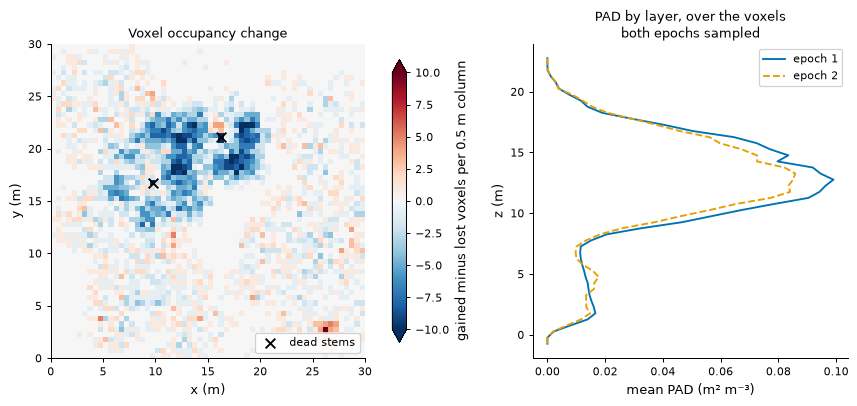

In [12]:
lay = occ.layers
fig, ax = plt.subplots(1, 2, figsize=(10, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
cols = [np.bincount(np.ravel_multi_index(((occ.centers(n)[:, 1] // 0.5).astype(int),
                                          (occ.centers(n)[:, 0] // 0.5).astype(int)), (60, 60)),
                    minlength=3600).reshape(60, 60) for n in ("lost", "gained")]
im = ax[0].imshow(cols[1] - cols[0], origin="lower", extent=(0, 30, 0, 30), cmap=DIVERGING, vmin=-10, vmax=10)
ax[0].scatter(*dead.T, marker="x", c="k", s=60, label="dead stems")
fig.colorbar(im, ax=ax[0], shrink=0.9, label="gained minus lost voxels per 0.5 m column", extend="both")
ax[0].set(xlabel="x (m)", ylabel="y (m)", title="Voxel occupancy change"); ax[0].legend(loc="lower right")
ax[1].plot(lay["pad_a"], lay["z"], label="epoch 1")
ax[1].plot(lay["pad_b"], lay["z"], "--", label="epoch 2")
ax[1].set(xlabel="mean PAD (m² m⁻³)", ylabel="z (m)", title="PAD by layer, over the voxels\nboth epochs sampled")
ax[1].legend(loc="upper right");

## Change in a QSM

`compare_qsms` compares two cylinder models of one tree in one frame: the
radius increment along the stem, branches matched, lost and new, and volume
change split into what both models measured (`trusted_change`) and what came
from the priors that fill in a QSM where no points were fitted. Given a
ray-traced grid of the later epoch, a branch missing from the later model is
only called lost when the later pulses saw its space empty.

The tree here is the survivor that lost a limb. Its wood points are taken
from the scans' true labels, to keep this section about the comparison
rather than about segmentation.

In [13]:
tree = ep.of_kind("branch_removed")[0]["tree_id"]
k = list(truth_1["tree_id"]).index(tree)
base = (truth_1["x"][k], truth_1["y"][k])


def wood(c):
    return c[(c.attrs["tree_id"] == tree) & (c.attrs["classification"] == 5)]


qsm_1, qsm_2 = qsm.build_qsm(wood(cloud_1), base_xy=base), qsm.build_qsm(wood(cloud_2a), base_xy=base)
w = wood(cloud_1).xyz
grid_2 = voxels.ray_voxelize(shots_2a, 0.1, bounds=(tuple(w.min(0) - 1), tuple(w.max(0) + 1)), occlusion=True)
qc = change.compare_qsms(qsm_1, qsm_2, grid_b=grid_2)
{k: int(v) if k.startswith("n_") else round(float(v), 4) for k, v in qc.summary().items()}

{'volume_a_m3': 0.3825,
 'volume_b_m3': 0.3989,
 'change_m3': 0.0164,
 'trusted_change_m3': 0.0159,
 'untrusted_change_m3': 0.0005,
 'trusted_sigma_m3': 0.0028,
 'taper_increment_m': 0.0032,
 'taper_sigma_m': 0.0005,
 'height_change_m': 0.5966,
 'dbh_change_m': 0.0064,
 'n_matched': 6,
 'n_lost': 1,
 'n_unobserved': 0,
 'n_present': 0,
 'n_new': 0}

In [14]:
true = growth[tree]
print(f"taper increment {1000 * qc.taper_increment:.1f} ± {1000 * qc.taper_sigma:.1f} mm "
      f"over {qc.n_taper_bins} bins (true radius increment {500 * true['d_dbh']:.1f} mm)")
removed = ep.of_kind("branch_removed")[0]
print(f"lost branches: {qc.lost['status'].tolist()}, volume {1000 * qc.lost['volume'].sum():.1f} L "
      f"(true {1000 * removed['volume']:.1f} L), measured share {qc.lost['measured'].round(2).tolist()}, "
      f"trusted {qc.lost['trusted'].tolist()}")
print(f"volume change {1000 * qc.change:.1f} L, of which trusted {1000 * qc.trusted_change:.1f} "
      f"± {1000 * qc.trusted_sigma:.1f} L")

taper increment 3.2 ± 0.5 mm over 7 bins (true radius increment 3.1 mm)
lost branches: ['lost'], volume 6.7 L (true 9.9 L), measured share [0.06], trusted [False]
volume change 16.4 L, of which trusted 15.9 ± 2.8 L


The lost limb is found, and the later grid confirms that its space was
seen and is empty, so it is `lost` rather than `unobserved`. Only a small
share of the limb's length was fitted to points in epoch 1, however; the
rest of its radius came from the QSM's priors, so its volume is not counted
as trusted change. The trusted change is the stem growth, which the taper
increment measures to within its stated uncertainty.

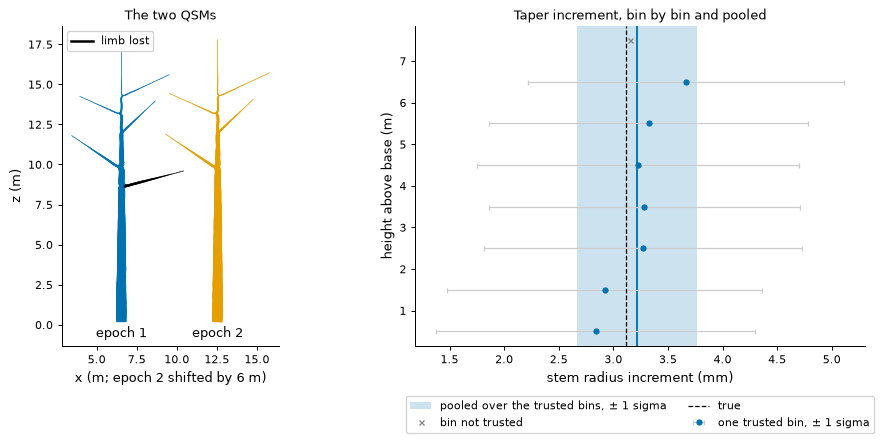

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.8), gridspec_kw={"width_ratios": [1, 1.2]})
lost_ids = set(qc.lost["id"].tolist())
for model, colour, dx, name in ((qsm_1, "C0", 0.0, "epoch 1"), (qsm_2, "C1", 6.0, "epoch 2")):
    s, e = model.start, model.start + model.cylinders[:, 3:6] * model.column("length")[:, None]
    for i in range(len(s)):
        lost_here = model is qsm_1 and model.column("branch_id")[i] in lost_ids
        ax[0].plot([s[i, 0] + dx, e[i, 0] + dx], [s[i, 2], e[i, 2]], c="k" if lost_here else colour,
                   lw=max(0.5, 60 * model.column("radius")[i]))
    ax[0].text(base[0] + dx, s[:, 2].min() - 1.0, name, ha="center", va="center")
ax[0].plot([], [], c="k", lw=2, label="limb lost")
ax[0].legend(loc="upper left")
ax[0].set(aspect="equal", ylim=(qsm_1.start[:, 2].min() - 1.8, None), xlabel="x (m; epoch 2 shifted by 6 m)", ylabel="z (m)",
          title="The two QSMs")
tp = qc.taper
mid = (tp["z0"] + tp["z1"]) / 2
ok = tp["trusted"]
pooled, sigma = 1000 * qc.taper_increment, 1000 * qc.taper_sigma
ax[1].axvspan(pooled - sigma, pooled + sigma, color="C0", alpha=0.2, lw=0, label="pooled over the trusted bins, ± 1 sigma")
ax[1].axvline(pooled, c="C0", lw=1.5)
ax[1].errorbar(1000 * tp["increment"][ok], mid[ok], xerr=1000 * tp["sigma"][ok], fmt="o", ms=4, c="C0",
               ecolor=CONTEXT, elinewidth=1, label="one trusted bin, ± 1 sigma")
ax[1].plot(1000 * tp["increment"][~ok], mid[~ok], "x", c="0.5", label="bin not trusted")
ax[1].axvline(500 * true["d_dbh"], c="k", ls="--", lw=1, label="true")
ax[1].set(xlabel="stem radius increment (mm)", ylabel="height above base (m)", title="Taper increment, bin by bin and pooled")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2);